In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from random import randrange
import random

class Chebyshev:
    """
    Chebyshev(a, b, n, func)
    Given a function func, lower and upper limits of the interval [a,b],
    and maximum degree n, this class computes a Chebyshev approximation
    of the function.
    Method eval(x) yields the approximated function value.
    """
    def __init__(self, a, b, n, func):
        n = n + 1
        self.a = a
        self.b = b
        self.func = func

        bma = 0.5 * (b - a)
        bpa = 0.5 * (b + a)
        f = [func(math.cos(math.pi * (k + 0.5) / n) * bma + bpa) for k in range(n)]
        self.roots = f

        self.x = [math.cos(math.pi * (k + 0.5) / n) * bma + bpa for k in range(n)]

        fac = 2.0 / n
        self.c = [fac * sum([f[k] * math.cos(math.pi * j * (k + 0.5) / n)
                  for k in range(n)]) for j in range(n)]

    def eval(self, x):
        a,b = self.a, self.b
        #assert(a <= x <= b)
        y = (2.0 * x - a - b) * (1.0 / (b - a))
        y2 = 2.0 * y
        (d, dd) = (self.c[-1], 0)             # Special case first step for efficiency
        for cj in self.c[-2:0:-1]:            # Clenshaw's recurrence
            (d, dd) = (y2 * d - dd + cj, d)
        return y * d - dd + 0.5 * self.c[0]   # Last step is different

In [28]:
b = 8

c = Chebyshev(0, 2**b, 495, math.sqrt)

In [35]:
def sqrt_ckks(x):
    k = max(0, (x.bit_length() - b + 1 + 1) // 2) 
    y = x >> (2*k)  # divide per 4^k senza overflow
    print("Res cheby: " + str(c.eval(y)))
    return (1 << k) * c.eval(y)

In [36]:
val = 2448939814439814

sqrt_ckks(val)

Res cheby: 5.830952134125678


48913571.71994373

In [37]:
math.sqrt(val)

49486764.03281805

---
Con interpolazione

In [149]:
import numpy as np
import math

def trig_poly_round_sqrt():
    N = 257
    seq = np.array([round(math.sqrt(i)) for i in range(N)], dtype=float)
    
    c = np.fft.fft(seq)  # tutti N coefficienti complessi

    def f(x):
        s = 0.0
        for k in range(N):
            ang = 2 * math.pi * k * x / N
            s += c[k].real * math.cos(ang) - c[k].imag * math.sin(ang)
        return s / N

    return f

f = trig_poly_round_sqrt()

# Verifica sui punti di interpolazione
print("Verifica interpolazione:")
for x in [0, 1, 2, 3, 4, 9, 16, 25, 100, 144, 225, 256]:
    val = f(x)
    expected = math.sqrt(x)
    print(f"  x={x:3d}: f(x)={val:.6f}, sqrt(x)={expected:.6f}, err={abs(val-expected):.2e}")

Verifica interpolazione:
  x=  0: f(x)=0.000000, sqrt(x)=0.000000, err=3.10e-15
  x=  1: f(x)=1.000000, sqrt(x)=1.000000, err=1.78e-15
  x=  2: f(x)=1.000000, sqrt(x)=1.414214, err=4.14e-01
  x=  3: f(x)=2.000000, sqrt(x)=1.732051, err=2.68e-01
  x=  4: f(x)=2.000000, sqrt(x)=2.000000, err=5.33e-15
  x=  9: f(x)=3.000000, sqrt(x)=3.000000, err=4.44e-15
  x= 16: f(x)=4.000000, sqrt(x)=4.000000, err=1.07e-14
  x= 25: f(x)=5.000000, sqrt(x)=5.000000, err=2.66e-15
  x=100: f(x)=10.000000, sqrt(x)=10.000000, err=7.28e-14
  x=144: f(x)=12.000000, sqrt(x)=12.000000, err=9.95e-14
  x=225: f(x)=15.000000, sqrt(x)=15.000000, err=2.58e-13
  x=256: f(x)=16.000000, sqrt(x)=16.000000, err=6.70e-13


In [150]:
f = trig_poly_round_sqrt()

c = Chebyshev(0, 256, 871, f)

2.913136398774441e-10

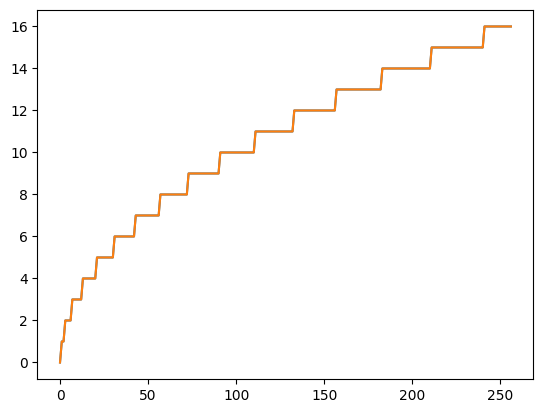

In [151]:
x = np.arange(0, 257, 1)

y = np.vectorize(c.eval)(x)
y_real = np.vectorize(f)(x)

plt.plot(x, y)
plt.plot(x, y_real)

max(abs(y - y_real))

In [307]:
def sqrt_ckks(x):
    if x == 0:
        return 0
    k = max(0, (x.bit_length() - 8 + 1) // 2)  # non "- b + 1 + 1"
    y = x >> (2 * k)
    return (1 << k) * c.eval(y)

In [457]:
def isqrt_newton(n, iters = 4, hint = 0):
    # Stima iniziale: potenza di 2 più vicina
    if (hint == 0):
        x = 2**64
    else:
        x = hint
    
    for _ in range(iters):
        x = (x + n // x) >> 1 
    return x

In [458]:
val = random.getrandbits(128)
print(val)

37545786231641837568184094127405655009


In [459]:
val = 130120321

In [460]:
# 70 is the number of iters required to compute the sqrt of 1
abs(round(math.isqrt(val)) - isqrt_newton(val, 70))

0

In [461]:
abs(round(math.isqrt(val)) - isqrt_newton(val, 4, int(round(sqrt_ckks(val)))))

0

### Notes

- Prove the minumum amont of iterations given our Chebyshev hint
- I conjecture around 4, which means that under the flexible-ckks framework we require 4 mults (20 sec * 4) plus a 871 degree cheby eval (around 10 secs?).
- PROBLEM: division :(


- Extra: we can do it for 4 elements in parallel, i conjecture that if we only require 1 element, we might speed up runtimes even further (maybe 15 secs per mult?). In jonathan work it takes like 8/9 minutes if im not wrong, so we are already winning here by like 9x times